# 02 - Exploratory Data Analysis (EDA)

[Back to the ETL notebook](01_etl.ipynb)

This notebook explores the cleaned HMRC data to answer our business questions: which taxes matter most, how receipts change through the year, and how they have moved since 2017.

In [1]:
# Cell 1
# Bring in pandas, our tool for working with tables
import pandas as pd


def load_clean_data(file_path="../data/processed/hmrc_clean.csv"):
    """Load the cleaned HMRC data with Month as the row label."""
    # Read the file, turning Month back into real dates
    data = pd.read_csv(file_path, parse_dates=["Month"])

    # Use Month as the row label and hand the table back
    return data.set_index("Month")


def seasonal_index(data):
    """Compare each month with the typical level around it (1.0 = a normal month)."""
    # A 12-month average centred on each month smooths out the long-term trend
    typical = data.rolling(12, center=True).mean()

    # Dividing by that average leaves only the seasonal pattern
    return data / typical


def financial_year(dates):
    """Give the UK financial year (April to March) that each date belongs to."""
    # January to March belong to the year that began the previous April
    return dates.year.where(dates.month >= 4, dates.year - 1)


def shorten_tax_names(table):
    """Swap long tax names for short ones so chart labels fit."""
    # The long names on the left become the short names on the right
    short_names = {"National Insurance Contributions": "NICs",
                   "Value Added Tax": "VAT",
                   "Hydrocarbon Oil (Fuel duties)": "Fuel duties"}

    # Rename both the rows and the columns, because a correlation table has names on both
    return table.rename(index=short_names, columns=short_names)

def show_chart(fig, file_name):
    """Show a Plotly chart as a picture GitHub can display, and save copies in outputs."""
    # Save a sharp picture of the chart in the outputs folder
    fig.write_image(f"../outputs/{file_name}.png", width=1000, height=500, scale=2)

    # Save an interactive copy too, which opens in any web browser
    fig.write_html(f"../outputs/{file_name}.html")

    # Show the picture version in the notebook, so it appears on GitHub as well
    fig.show(renderer="png", width=1000, height=500) #it shows the chart in the notebook as a picture

# Use our function to load the data
df = load_clean_data()

# Check the size, which should be (113, 44)
print(df.shape)

(113, 44)


**Cell 1**

**Action:** Defined four reusable functions (`load_clean_data`, `seasonal_index`, `financial_year` and `shorten_tax_names`), then used `load_clean_data` to load the cleaned HMRC data.

**Result:** 113 rows and 44 columns, with `Month` as the row label.

**Note:** Writing these as functions means the same logic is written once and reused in later cells, instead of being copied.

In [2]:
# Cell 2
# The biggest and most important taxes, to look at first
main_taxes = ["Total HMRC Receipts", "Income Tax", "National Insurance Contributions",
              "Value Added Tax", "Corporation Tax"]

# describe() gives the count, mean, spread (std), min, quartiles and max
# The 50% row is the median. Everything is in £ million, rounded to whole numbers
df[main_taxes].describe().round(0)

,Total HMRC Receipts,Income Tax,National Insurance Contributions,Value Added Tax,Corporation Tax
count,113.0,113.0,113.0,113.0,113.0
mean,61517.0,20123.0,13542.0,12442.0,5882.0
std,16666.0,7702.0,2335.0,4378.0,4076.0
min,26023.0,11001.0,9425.0,-896.0,904.0
25%,50272.0,14500.0,11566.0,9162.0,2453.0
50%,59566.0,18765.0,13496.0,12850.0,4314.0
75%,68886.0,22699.0,14685.0,15230.0,8375.0
max,126444.0,51255.0,20918.0,21753.0,18322.0


**Cell 2**

**Action:** Calculated summary statistics for the total receipts and the four biggest taxes.

**Result:** Across the 113 months, total receipts averaged about £61.5bn a month, with a median of about £59.6bn. The spread (standard deviation) is about £16.7bn, so receipts swing a lot from month to month. The lowest month was about £26.0bn and the highest about £126.4bn.

**Note:** Value Added Tax has a minimum below zero, meaning that in at least one month refunds were larger than payments. We'll look at that in the charts.

In [3]:
# Cell 3
# Leave out the total columns and the sub-categories, so nothing is counted twice
exclude = ["Total Paid Over", "Total HMRC Receipts",
           "PAYE NIC1 (EMP'er)", "PAYE NIC1 (EMP'ee)", "SA NIC2&4"]
exclude += [c for c in df.columns if "included within" in c] #creates a list of columns to exclude from the analysis, including total columns and sub-categories, so that nothing is counted twice

# Work out the average monthly receipts for each remaining tax, biggest first
avg_by_tax = df.drop(columns=exclude).mean().sort_values(ascending=False).round(0) #calculates the average monthly receipts for each tax and sorts them in descending order

# Show the top 8
print(avg_by_tax.head(8))

Income Tax                          20123.0
National Insurance Contributions    13542.0
Value Added Tax                     12442.0
Corporation Tax                      5882.0
Hydrocarbon Oil (Fuel duties)        2125.0
Capital Gains Tax                    1093.0
Stamp Duty Land Tax                  1075.0
Energy Profits Levy                   954.0
dtype: float64


**Cell 3**

**Action:** Ranked the taxes by their average monthly receipts, leaving out totals and sub-categories so nothing was counted twice.

**Result:** Income Tax is the biggest at about £20.1bn a month, then National Insurance (£13.5bn), VAT (£12.4bn) and Corporation Tax (£5.9bn). Together those four make up most of what HMRC collects. Fuel duties come fifth at about £2.1bn.

In [4]:
# Cell 4
# Pull out the total receipts column to keep the lines below short
total = df["Total HMRC Receipts"]

# Find the month with the biggest total and the month with the smallest
print("Highest month:", total.idxmax().strftime("%B %Y"), "at", total.max())
print("Lowest month:", total.idxmin().strftime("%B %Y"), "at", total.min()) #shows the month with the lowest total receipts

Highest month: January 2026 at 126444.0
Lowest month: May 2020 at 26023.0


**Cell 4**

**Action:** Found the months with the highest and lowest total receipts.

**Result:** The highest month was January 2026 at about £126.4bn and the lowest was May 2020 at about £26.0bn.

**Note:** January is likely high because many Self Assessment tax bills are due that month. May 2020 falls in the first Covid lockdown, which probably explains the dip. We'll check both patterns in the charts.

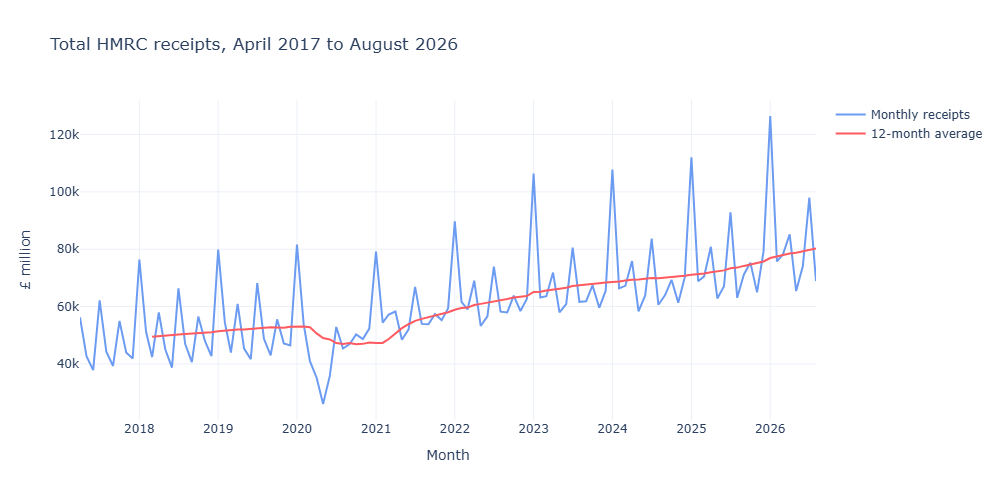

In [5]:
# Cell 5 # importing libraries
# Bring in Plotly Express, a tool for interactive charts
import plotly.express as px

# Smooth out the seasonal ups and downs with a 12-month rolling average
trend = total.rolling(12).mean() #calculates the 12-month rolling average of the total receipts

# Put the monthly figures and the trend line side by side in one table
# reset_index turns the Month index back into a normal column the chart can use
chart_data = pd.DataFrame({"Monthly receipts": total, "12-month average": trend}).reset_index() #creates a new DataFrame with the monthly receipts and the 12-month average, and resets the index so that Month is a normal column

# Draw the line chart with the two lines
fig = px.line(
    chart_data,
    x="Month",
    y=["Monthly receipts", "12-month average"],
    title="Total HMRC receipts, April 2017 to August 2026",
    labels={"value": "£ million", "variable": ""},
    color_discrete_sequence=["#6c9bf2", "#ff5a5f"],
) #creates the line chart with the monthly receipts and the 12-month average

# Use a clean white background and show both values when hovering
fig.update_layout(template="plotly_white", hovermode="x unified")

# Display the chart
show_chart(fig, "total_receipts_trend")

**Cell 5**

**Action:** Plotted total monthly receipts as an interactive line chart, with a 12-month rolling average on top to smooth out the seasonal swings.

**Business question:** How have total receipts changed since 2017?

**Result:** **Result:** Total receipts rose steadily from 2017 until the Covid dip in 2020, when the 12-month average fell to its lowest point (about £46.9bn in October 2020). Receipts recovered through 2021 and have climbed steadily since early 2022, reaching their highest level in 2026. January shows up as a regular spike every year.

**Note:** These figures are not adjusted for inflation, so part of the long-term rise reflects higher prices, not only more tax collected.

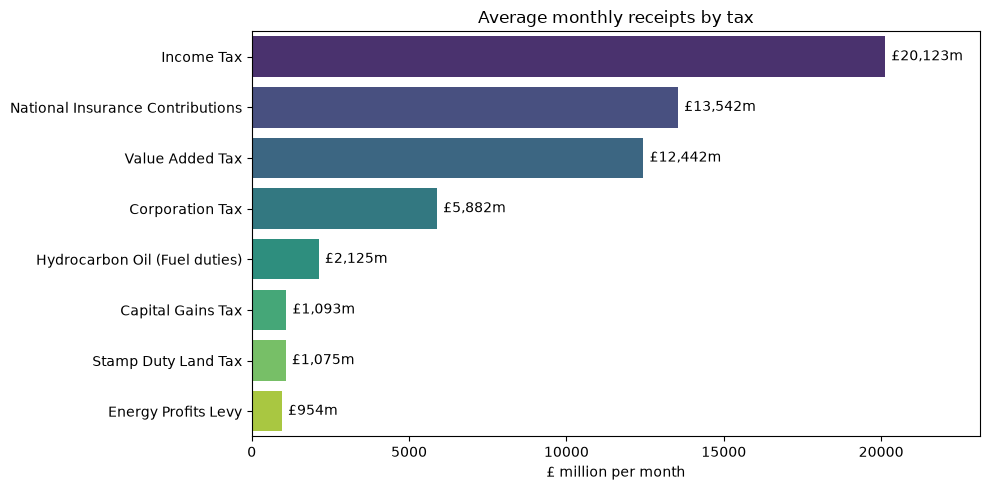

In [6]:
# Cell 6 #importing libraries
# Bring in matplotlib and seaborn, the usual tools for static charts
import matplotlib.pyplot as plt
import seaborn as sns

# Take the top 8 taxes from Cell 3 and turn them into a small table for plotting
top8 = avg_by_tax.head(8).reset_index() #takes the top 8 taxes and turns them into a small table for plotting
top8.columns = ["Tax", "Average monthly receipts"] #renames the columns to something shorter and easier to read

# Make the chart wide enough to read the tax names
plt.figure(figsize=(10, 5))

# Draw horizontal bars, giving each tax its own colour
sns.barplot(data=top8, y="Tax", x="Average monthly receipts", hue="Tax", palette="viridis", legend=False)
#it draws horizontal bars for each tax, with the length of the bar representing the average monthly receipts, and each bar having its own colour

# Write the value at the end of each bar
for i, v in enumerate(top8["Average monthly receipts"]): #loops through each bar, with i = the row number and v = the value
    plt.text(v + 200, i, f"£{v:,.0f}m", va="center") # it adds the text labels to the bars, with a small offset to the right

# Leave a little room on the right so the labels don't get cut off
plt.xlim(0, top8["Average monthly receipts"].max() * 1.15) #this code sets the x-axis limit to 15% more than the maximum value, so the labels fit

# Add a title and axis labels
plt.title("Average monthly receipts by tax")
plt.xlabel("£ million per month")
plt.ylabel("")

# Tidy the spacing and show the chart
plt.tight_layout()# this code adjusts the spacing of the chart to make it look nicer
plt.show()

**Cell 6**

**Action:** Drew a bar chart of the eight taxes with the highest average monthly receipts.

**Business question:** Which taxes bring in the most money for the UK?

**Result:** Income Tax is clearly the biggest, at about £20.1bn a month. National Insurance (£13.5bn) and VAT (£12.4bn) come next, and then Corporation Tax (£5.9bn). After those four, the rest are much smaller, with fuel duties at about £2.1bn.

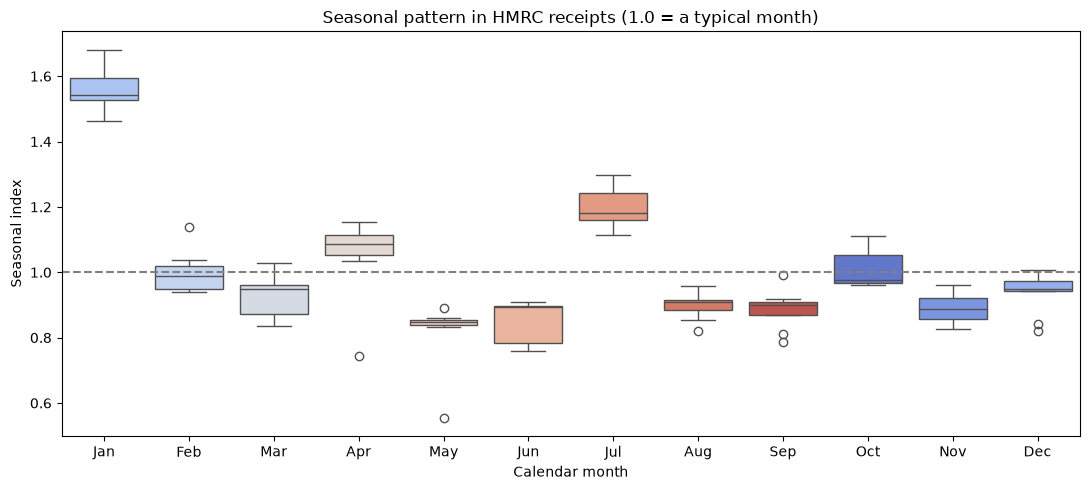

In [7]:
# Cell 7
# Use the seasonal_index function from Cell 1 to compare each month with its typical level
season_values = seasonal_index(total)

# Put the index and the month name side by side in one table
# str[:3] shortens "January" to "Jan"; dropna() removes the edge months with no average
season_data = pd.DataFrame({
    "Seasonal index": season_values,
    "Calendar month": season_values.index.month_name().str[:3],
}).dropna()

# Put the months in calendar order, because the chart would otherwise sort them A to Z
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Make the chart a good size
plt.figure(figsize=(11, 5))

# Draw one box for each calendar month, coloured from cool to warm
sns.boxplot(data=season_data, x="Calendar month", y="Seasonal index",
            order=month_order, hue="Calendar month", palette="coolwarm", legend=False)

# Draw a dashed line at 1.0 so it's easy to see which months sit above or below normal
plt.axhline(1, color="grey", linestyle="--")

# Add a title and tidy the spacing
plt.title("Seasonal pattern in HMRC receipts (1.0 = a typical month)")
plt.tight_layout()
plt.show()

**Cell 7**

**Action:** Compared each month's receipts with the typical level around it, then drew a box plot for each calendar month to show how the pattern repeats from year to year. Uses function: seasonal_index from (Cell 1)

**Business question:** Do receipts follow a seasonal pattern?

**Result:** Yes, a very clear one. January is far above normal, with a typical month about 54% higher than usual. July (about 18% above) and April (about 9% above) are also high. May is the weakest month, at about 15% below normal.

**Note:** The box shows where the middle half of the years sit, the line inside is the median, and dots are unusual years. January has a tall box, which tells us how much its size varies from year to year. January is likely high because many Self Assessment bills are due then, but this chart shows the pattern, not the cause.

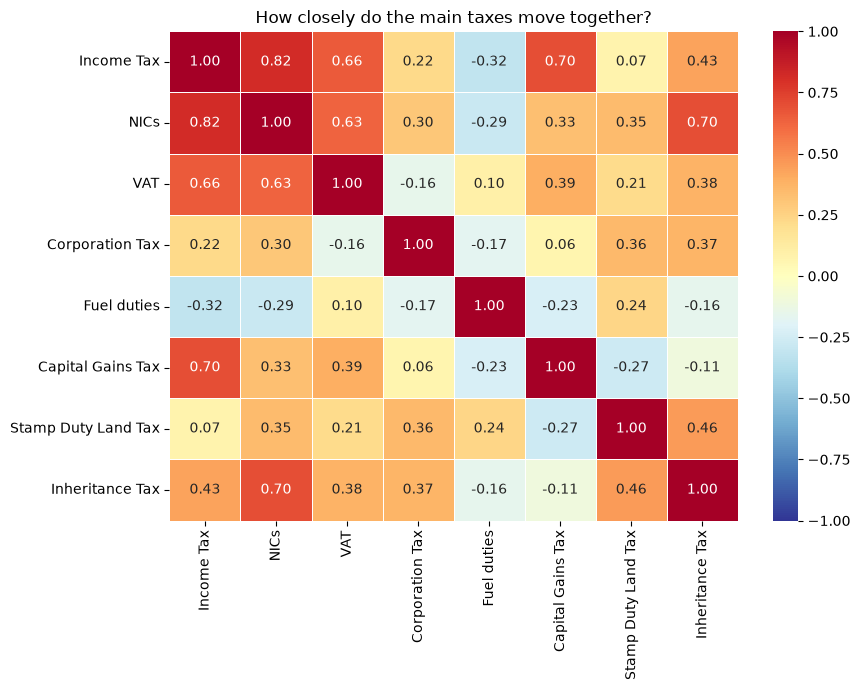

In [8]:
# Cell 8
# Pick eight important taxes to compare
tax_list = ["Income Tax", "National Insurance Contributions", "Value Added Tax",
            "Corporation Tax", "Hydrocarbon Oil (Fuel duties)", "Capital Gains Tax",
            "Stamp Duty Land Tax", "Inheritance Tax"]

# Work out how strongly each pair of taxes moves together
corr = df[tax_list].corr() #calculates the correlation matrix for the selected taxes, showing how strongly each pair of taxes moves together

# Use the shorter names so the labels fit (function from Cell 1)
corr = shorten_tax_names(corr)

# Make the chart square-ish so the boxes look even
plt.figure(figsize=(9, 7))

# Draw the heatmap: annot=True writes the score in each box
# vmin and vmax fix the colour scale from -1 to +1, red = move together, blue = move apart
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r",
            vmin=-1, vmax=1, linewidths=0.5) #this code draws the heatmap, with the correlation scores written in each box, and the colour scale fixed from -1 to +1, where red means the taxes move together and blue means they move apart

# Add a title and tidy the spacing
plt.title("How closely do the main taxes move together?")
plt.tight_layout()
plt.show()

**Cell 8**

**Action:** Calculated the correlation between eight of the main taxes and drew it as a colour-coded heatmap.Used function: shorten_tax_names (Cell 1)

**Business question:** Do some taxes move together?

**Result:** The strongest link is between Income Tax and National Insurance (0.82), which makes sense because both are collected through payroll. Income Tax and Capital Gains Tax are also closely linked (0.70), and so are National Insurance and Inheritance Tax (0.70). Fuel duties have weak or slightly negative links with most taxes, so they behave differently from the rest.

**Note:** Correlation shows that two taxes move together, not that one causes the other. Part of what we see comes from shared patterns, like the January spike and the general upward trend. We'll test the Income Tax and NICs link properly in the statistics notebook.

In [9]:
# Cell 9
# Pick the four biggest taxes
big4 = ["Income Tax", "National Insurance Contributions", "Value Added Tax", "Corporation Tax"]

# Start a table with those four
mix = df[big4].copy() #creates a new DataFrame with the four biggest taxes

# Add one more column for everything else: the total minus the big four
mix["All other taxes"] = df["Total HMRC Receipts"] - df[big4].sum(axis=1) #calculates the receipts for all other taxes by subtracting the sum of the big four taxes from the total HMRC receipts and adds it as a new column to the mix DataFrame

# Smooth each column with a 12-month average, so seasonal spikes don't hide the long-term story
# dropna() removes the first 11 months, which don't have a full year of data yet
smooth = mix.rolling(12).mean().dropna()

# Turn the table into "long" format, which Plotly needs: one row per month per tax
long_mix = smooth.reset_index().melt(id_vars="Month", var_name="Tax", value_name="Receipts (£ million)")

# Draw the stacked area chart
# groupnorm="percent" makes every month add up to 100%, so we see the share of each tax
fig = px.area(
    long_mix,
    x="Month",
    y="Receipts (£ million)",
    color="Tax",
    groupnorm="percent",
    title="Share of HMRC receipts by tax (12-month average)",
    color_discrete_sequence=px.colors.qualitative.Set2,
) #creates the stacked area chart, with each tax represented by a different colour, and the y-axis showing the share of each tax as a percentage of total receipts


# Label the vertical axis as a percentage, use a white background and show all values on hover
fig.update_layout(template="plotly_white", yaxis_title="Share of receipts (%)", hovermode="x unified")

# Display the chart
fig.show()

In [10]:
# Cell 10
# Work out which financial year each month belongs to (function from Cell 1)
fin_year = financial_year(df.index)

# Add up total receipts for each financial year, and count how many months each year has
yearly = df["Total HMRC Receipts"].groupby(fin_year).agg(["sum", "count"])

# Keep only complete years (12 months), because the current year isn't finished yet
yearly = yearly[yearly["count"] == 12].copy()

# Label each year the way HMRC does, for example 2017/18
yearly["Financial year"] = [f"{y}/{str(y + 1)[2:]}" for y in yearly.index]

# Convert £ million to £ billion so the numbers are easier to read
yearly["Receipts (£bn)"] = (yearly["sum"] / 1000).round(1)

# Work out the growth compared with the year before, as a percentage
yearly["Growth (%)"] = (yearly["sum"].pct_change() * 100).round(1)

# Draw the bars, coloured by growth: green for growth, red for decline
fig = px.bar(yearly, x="Financial year", y="Receipts (£bn)", text="Receipts (£bn)",
             color="Growth (%)", color_continuous_scale="RdYlGn", color_continuous_midpoint=0,
             title="Total HMRC receipts by financial year")

# Put the value above each bar and use a clean white background
fig.update_traces(textposition="outside")
fig.update_layout(template="plotly_white")

# Display the chart
fig.show()

**Cell 10**

**Action:** Added up total receipts for each complete financial year (April to March) and calculated the growth on the year before. Used function: financial_year (Cell 1)

**Business question:** How fast are receipts growing, and which years stand out?

**Result:** Receipts grew from about £593bn in 2017/18 to about £938bn in 2025/26. Growth was modest until 2019/20, then receipts fell 7.8% in 2020/21 (the Covid year). They rebounded 22.5% in 2021/22 and have grown every year since, between 3.6% and 10.0%.

**Note:** The 2026/27 year is left out because only five months (April to August 2026) are available. Figures are not adjusted for inflation.

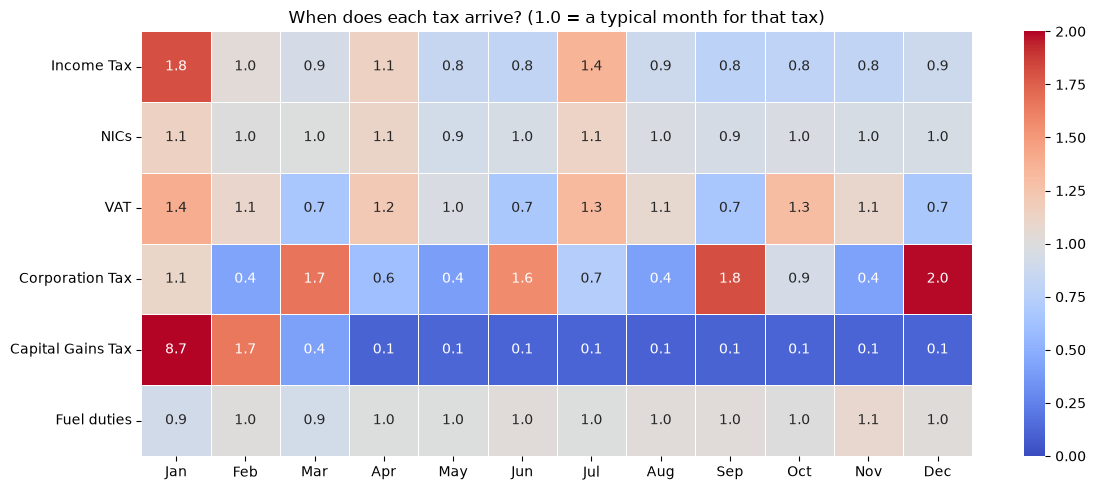

In [11]:
# Cell 11
# Pick six taxes with different payment patterns
timing_taxes = ["Income Tax", "National Insurance Contributions", "Value Added Tax",
                "Corporation Tax", "Capital Gains Tax", "Hydrocarbon Oil (Fuel duties)"]

# Seasonal index for each tax, using the function from Cell 1
index_by_tax = seasonal_index(df[timing_taxes])

# Take the median for each calendar month (1 to 12), then flip so taxes run down the side
by_month = index_by_tax.groupby(index_by_tax.index.month).median().T

# Rename the columns from 1-12 to month names
by_month.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Use shorter tax names so the labels fit (function from Cell 1)
by_month = shorten_tax_names(by_month)

# Make the chart wide enough for twelve columns
plt.figure(figsize=(12, 5))

# Draw the heatmap: red is above normal, blue is below normal, centred on 1.0
# vmax=2 caps the colour scale so one huge value doesn't wash out the rest
sns.heatmap(by_month, annot=True, fmt=".1f", cmap="coolwarm",
            center=1, vmin=0, vmax=2, linewidths=0.5)

# Add a title and tidy the spacing
plt.title("When does each tax arrive? (1.0 = a typical month for that tax)")
plt.tight_layout()
plt.show()

**Cell 11**

**Action:** Calculated a seasonal index for six taxes and drew a heatmap showing which months each one is collected in.Used functions: seasonal_index and shorten_tax_names (Cell 1)

**Business question:** When does each tax arrive, and what causes the January spike?

**Result:** Each tax has its own rhythm. VAT peaks every quarter (January, April, July and October). Corporation Tax peaks in March, June, September and December. Income Tax peaks in January (about 1.8 times a normal month) and again in July. Capital Gains Tax is almost all collected in January, at about 8.7 times a typical month. National Insurance has gentle peaks, and fuel duties are flat all year.

**Note:** January stands out because Income Tax, Capital Gains Tax and VAT all peak together. The colour scale stops at 2.0, so the Capital Gains Tax box looks the same shade as other high months, but the number printed in it shows the true size.

## EDA summary

This notebook explored the cleaned HMRC data (113 months, April 2017 to August 2026) to answer our business questions.

1,Business question 2, Answer & Evidence 

1,Which taxes bring in the most money? 
Income Tax, then National Insurance, VAT and Corporation Tax 
Average monthly receipts of about £20.1bn, £13.5bn, £12.4bn and £5.9bn (Cells 3 and 6).

2,Is there a seasonal pattern? 
Yes, a strong one,January is about 54% above a typical month and May about 15% below (Cell 7).

3,When does each tax arrive? 
Each tax has its own rhythm  VAT peaks quarterly, Corporation Tax peaks in March, June, September and December, and Capital Gains Tax arrives almost entirely in January (Cell 11).

4,How have receipts changed since 2017? 
They grew strongly, apart from the Covid dip 
About £593bn in 2017/18 to about £938bn in 2025/26, with a fall of 7.8% in 2020/21 and a rebound of 22.5% the year after (Cells 5 and 10).

5,Do some taxes move together? 
Yes, Income Tax and National Insurance have the strongest link, at 0.82 (Cell 8).

6,How has the tax mix shifted? 
Income Tax carries more of the load. Its share rose from about 30% to about 35% (Cell 9).

7,Can we predict future receipts?  
To be answered in the machine learning notebook.


**Hypotheses to test next:**
1. Receipts in January are significantly higher than in other months.
2. Income Tax and National Insurance receipts are positively correlated.

**Limitations:** figures are not adjusted for inflation, the latest months are provisional, and correlation does not show that one tax causes another.


**Next notebook:** [Continue to the statistics notebook](03_statistics.ipynb)